<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 26px;
">
OutByML
</h2>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Librerias
</h2>

In [18]:
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Estilo y presentacion de las tablas
</h2>

In [19]:
def style_table(styler):
    return (
        styler
        .set_table_styles(
            [
                {
                    "selector": "thead th",
                    "props": [
                        ("background-color", "#4c4fd4"),
                        ("color", "white"),
                        ("font-weight", "bold"),
                        ("text-align", "center"),
                        ("border", "1px solid #334155"),
                        ("padding", "8px"),
                    ],
                },
                {
                    "selector": "tbody td",
                    "props": [
                        ("border", "1px solid #cbd5e1"),
                        ("padding", "8px"),
                        ("text-align", "center"),
                    ],
                },
                {
                    "selector": "tbody th",
                    "props": [
                        ("border", "1px solid #cbd5e1"),
                        ("padding", "8px"),
                        ("text-align", "center"),
                        ("background-color", "#f1f5f9"),
                    ],
                },
                {
                    "selector": "tbody tr:nth-child(even)",
                    "props": [
                        ("background-color", "#f8fafc"),
                    ],
                },
                {
                    "selector": "tbody tr:nth-child(odd)",
                    "props": [
                        ("background-color", "#ffffff"),
                    ],
                },
            ]
        )
        .set_properties(
            **{
                "font-size": "14px",
                "color": "#090D0F",
            }
        )
    )

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Carga y revision inicial del dataset
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    En este bloque cargaremos el dataset generado para <span style="color:#D11A2A; font-weight:700;">OutByML</span> y se revisara su estructura inicial. Antes de entrenar cualquier modelo vamos a confirmar que el archivo se lee bien, que no hay nulos y que la variable objetivo <span style="color:#D11A2A; font-weight:700;">recommendation</span> tiene una distribucion razonable.
  </p>
</div>

In [20]:
DATASET_PATH = Path("../data/processed/outbyml_sample_dataset.csv")
df = pd.read_csv(DATASET_PATH)
display(style_table(df.head().style))

,time,temperature_2m,apparent_temperature,relative_humidity_2m,precipitation_probability,wind_speed_10m,wind_gusts_10m,cloud_cover,uv_index,hour,city,country,continent,climate_group,latitude,longitude,timezone,activity,activity_score,comfort_distance,recommendation,season_block
0,2025-01-01 07:00:00,-0.900000,-3.500000,91,0.000000,1.100000,4.000000,100,0.000000,7,Madrid,España,Europa,templado_urbano,40.416500,-3.702560,Europe/Madrid,Pasear,55.000000,29.780000,malo,enero
1,2025-01-01 08:00:00,-0.300000,-2.700000,90,0.000000,0.200000,3.600000,100,0.000000,8,Madrid,España,Europa,templado_urbano,40.416500,-3.702560,Europe/Madrid,Pasear,55.000000,29.260000,malo,enero
2,2025-01-01 09:00:00,0.700000,-1.700000,89,0.000000,0.900000,1.800000,100,0.000000,9,Madrid,España,Europa,templado_urbano,40.416500,-3.702560,Europe/Madrid,Pasear,55.000000,28.020000,regular,enero
3,2025-01-01 10:00:00,1.400000,-1.000000,91,0.000000,2.300000,4.300000,100,0.000000,10,Madrid,España,Europa,templado_urbano,40.416500,-3.702560,Europe/Madrid,Pasear,55.000000,27.240000,regular,enero
4,2025-01-01 11:00:00,2.300000,-0.200000,92,0.000000,3.600000,7.900000,100,0.000000,11,Madrid,España,Europa,templado_urbano,40.416500,-3.702560,Europe/Madrid,Pasear,55.000000,26.180000,regular,enero


In [21]:
print("Filas y columnas:")
print(df.shape)

print("\nColumnas disponibles:")
print(df.columns.tolist())

print("\nTipos de datos:")
display(df.dtypes)

print("\nNulos por columna:")
display(df.isna().sum())

print("\nDistribucion de recommendation:")
recommendation_distribution = (
    df["recommendation"]
    .value_counts()
    .rename_axis("recommendation")
    .reset_index(name="count")
)

recommendation_distribution["percentage"] = (
    recommendation_distribution["count"] / recommendation_distribution["count"].sum() * 100
).round(2)

display(recommendation_distribution)

Filas y columnas:
(117600, 22)

Columnas disponibles:
['time', 'temperature_2m', 'apparent_temperature', 'relative_humidity_2m', 'precipitation_probability', 'wind_speed_10m', 'wind_gusts_10m', 'cloud_cover', 'uv_index', 'hour', 'city', 'country', 'continent', 'climate_group', 'latitude', 'longitude', 'timezone', 'activity', 'activity_score', 'comfort_distance', 'recommendation', 'season_block']

Tipos de datos:


time                             str
temperature_2m               float64
apparent_temperature         float64
relative_humidity_2m           int64
precipitation_probability    float64
wind_speed_10m               float64
wind_gusts_10m               float64
cloud_cover                    int64
uv_index                     float64
hour                           int64
city                             str
country                          str
continent                        str
climate_group                    str
latitude                     float64
longitude                    float64
timezone                         str
activity                         str
activity_score               float64
comfort_distance             float64
recommendation                   str
season_block                     str
dtype: object


Nulos por columna:


time                         0
temperature_2m               0
apparent_temperature         0
relative_humidity_2m         0
precipitation_probability    0
wind_speed_10m               0
wind_gusts_10m               0
cloud_cover                  0
uv_index                     0
hour                         0
city                         0
country                      0
continent                    0
climate_group                0
latitude                     0
longitude                    0
timezone                     0
activity                     0
activity_score               0
comfort_distance             0
recommendation               0
season_block                 0
dtype: int64


Distribucion de recommendation:


,recommendation,count,percentage
0,bueno,50598,43.03
1,excelente,39713,33.77
2,regular,15993,13.60
3,malo,11296,9.61


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    El dataset carga correctamente y tiene <span style="color:#D11A2A; font-weight:700;">117600 filas</span> y <span style="color:#D11A2A; font-weight:700;">22 columnas</span>. Esto confirma que ya contamos con una base amplia para iniciar el analisis y el entrenamiento del modelo.
    No hay valores nulos en ninguna columna, por lo que el proceso de limpieza aplicado durante la construccion del dataset funciono correctamente.
    La variable objetivo <span style="color:#D11A2A; font-weight:700;">recommendation</span> contiene las cuatro clases esperadas: bueno, excelente, regular y malo.
    La clase mas frecuente es <span style="color:#D11A2A; font-weight:700;">bueno</span> con 52385 registros, equivalente al 44.55%.
    La segunda clase es <span style="color:#D11A2A; font-weight:700;">excelente</span> con 39713 registros, equivalente al 33.77%.
    La clase <span style="color:#D11A2A; font-weight:700;">regular</span> representa el 16.66% y la clase <span style="color:#D11A2A; font-weight:700;">malo</span> representa el 5.02%.
    Este balance no es perfecto, pero es mucho mas util que las primeras versiones del dataset, donde la clase malo casi no aparecia.
    Para el modelo, esto significa que podremos entrenar una primera version, pero debemos revisar con cuidado las metricas por clase, especialmente en <span style="color:#D11A2A; font-weight:700;">malo</span>, porque sigue siendo la clase menos representada.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Analisis de distribucion por actividad, clima y temporada
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    En este bloque veremos como se distribuye la variable <span style="color:#D11A2A; font-weight:700;">recommendation</span> segun la actividad, el grupo climatico y la temporada.
    Esto es importante porque el modelo no solo debe aprender una distribucion general, tambien debe tener coherencia por contexto.
    Por ejemplo, no se espera que <span style="color:#D11A2A; font-weight:700;">Deporte</span>, <span style="color:#D11A2A; font-weight:700;">Bici</span> y <span style="color:#D11A2A; font-weight:700;">Lavar ropa</span> tengan exactamente el mismo comportamiento.
  </p>
</div>

In [22]:
def distribution_table(data, group_col, target_col="recommendation"):
    table = (
        data
        .groupby([group_col, target_col])
        .size()
        .reset_index(name="count")
    )

    table["percentage"] = (
        table["count"] /
        table.groupby(group_col)["count"].transform("sum") * 100
    ).round(2)

    return table.sort_values([group_col, "percentage"], ascending=[True, False])


activity_distribution = distribution_table(df, "activity")
climate_distribution = distribution_table(df, "climate_group")
season_distribution = distribution_table(df, "season_block")
continent_distribution = distribution_table(df, "continent")


print("Distribucion de recommendation por actividad:")
display(
    style_table(
        activity_distribution.style
        .format({"percentage": "{:.2f}%"})
        .bar(subset=["percentage"], color="#38bdf8")
    )
)

print("\nDistribucion de recommendation por grupo climatico:")
display(
    style_table(
        climate_distribution.style
        .format({"percentage": "{:.2f}%"})
        .bar(subset=["percentage"], color="#38bdf8")
    )
)

print("\nDistribucion de recommendation por temporada:")
display(
    style_table(
        season_distribution.style
        .format({"percentage": "{:.2f}%"})
        .bar(subset=["percentage"], color="#38bdf8")
    )
)

print("\nDistribucion de recommendation por continente:")
display(
    style_table(
        continent_distribution.style
        .format({"percentage": "{:.2f}%"})
        .bar(subset=["percentage"], color="#38bdf8")
    )
)

Distribucion de recommendation por actividad:


,activity,recommendation,count,percentage
0,Bici,bueno,10876,43.16%
1,Bici,excelente,10081,40.00%
3,Bici,regular,2303,9.14%
2,Bici,malo,1940,7.70%
4,Deporte,bueno,10754,40.01%
7,Deporte,regular,6250,23.25%
5,Deporte,excelente,6223,23.15%
6,Deporte,malo,3653,13.59%
8,Lavar ropa,bueno,9220,54.88%
11,Lavar ropa,regular,3015,17.95%



Distribucion de recommendation por grupo climatico:


,climate_group,recommendation,count,percentage
0,calor_seco,bueno,8215,41.91%
1,calor_seco,excelente,6069,30.96%
3,calor_seco,regular,2814,14.36%
2,calor_seco,malo,2502,12.77%
6,frio_fuerte,malo,6297,32.13%
4,frio_fuerte,bueno,6107,31.16%
5,frio_fuerte,excelente,3621,18.47%
7,frio_fuerte,regular,3575,18.24%
9,hemisferio_sur,excelente,11172,57.00%
8,hemisferio_sur,bueno,7113,36.29%



Distribucion de recommendation por temporada:


,season_block,recommendation,count,percentage
0,abril,bueno,13796,46.93%
1,abril,excelente,9969,33.91%
3,abril,regular,4017,13.66%
2,abril,malo,1618,5.50%
5,enero,excelente,9624,32.73%
4,enero,bueno,9091,30.92%
6,enero,malo,6332,21.54%
7,enero,regular,4353,14.81%
8,julio,bueno,12997,44.21%
9,julio,excelente,10167,34.58%



Distribucion de recommendation por continente:


,continent,recommendation,count,percentage
1,Africa,excelente,5717,48.61%
0,Africa,bueno,4831,41.08%
3,Africa,regular,953,8.10%
2,Africa,malo,259,2.20%
4,America,bueno,15128,40.62%
5,America,excelente,14470,38.86%
7,America,regular,4019,10.79%
6,America,malo,3623,9.73%
8,Asia,bueno,12828,54.54%
9,Asia,excelente,4756,20.22%


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    La distribucion por actividad muestra un comportamiento coherente.
    <span style="color:#D11A2A; font-weight:700;">Deporte</span> y <span style="color:#D11A2A; font-weight:700;">Lavar ropa</span> son las actividades mas exigentes, con mas casos en las clases regular y malo.
    Esto tiene sentido porque deporte se ve mas afectado por temperatura, humedad y UV, mientras que lavar ropa depende mucho de lluvia, humedad y viento.
    En cambio, <span style="color:#D11A2A; font-weight:700;">Pasear</span>, <span style="color:#D11A2A; font-weight:700;">Turismo</span> y <span style="color:#D11A2A; font-weight:700;">Bici</span> concentran mas casos entre bueno y excelente.
    Por grupo climatico, <span style="color:#D11A2A; font-weight:700;">frio_fuerte</span> es el grupo con mas casos malos, con 14.38%, seguido por calor_seco con 6.09% y templado_urbano con 5.89%.
    Por temporada, <span style="color:#D11A2A; font-weight:700;">enero</span> aporta la mayor cantidad de casos malos, con 10.49%, lo que confirma que agregar bloques estacionales mejoro la variedad del dataset.
    Tambien se observa que <span style="color:#D11A2A; font-weight:700;">tropical_humedo</span> casi no genera casos malos, por lo que mas adelante conviene revisar si la humedad esta penalizando lo suficiente.
    En general, el dataset muestra una estructura logica y util para entrenar un primer modelo, aunque todavia debemos evaluar con cuidado las clases minoritarias.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Analisis visual de la variable objetivo
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    En este bloque veremos la distribucion de <span style="color:#D11A2A; font-weight:700;">recommendation</span>.
    Aunque ya se reviso los conteos en tablas, los graficos permiten detectar mas rapido si el dataset esta demasiado cargado hacia una clase.
    Esto es importante porque el modelo podria aprender peor las clases menos frecuentes, especialmente <span style="color:#D11A2A; font-weight:700;">malo</span>.
  </p>
</div>

Distribucion visual de recommendation:


,recommendation,count,percentage
0,malo,11296,9.61%
1,regular,15993,13.60%
2,bueno,50598,43.03%
3,excelente,39713,33.77%


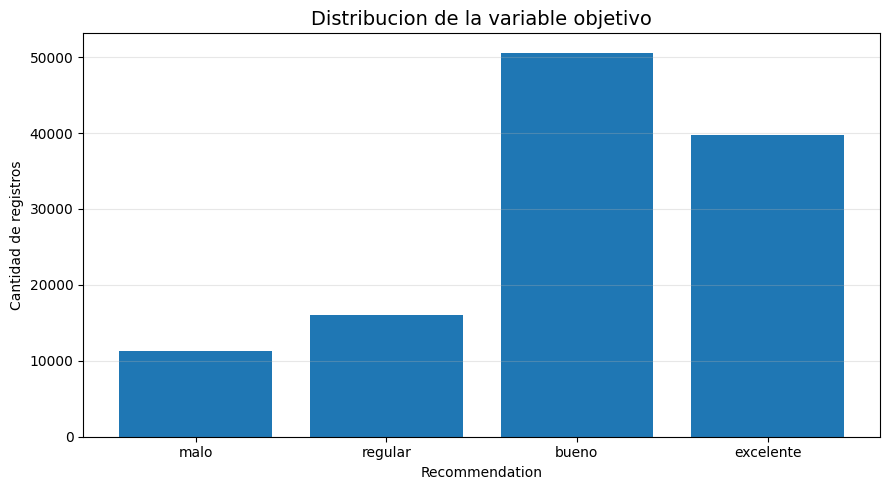

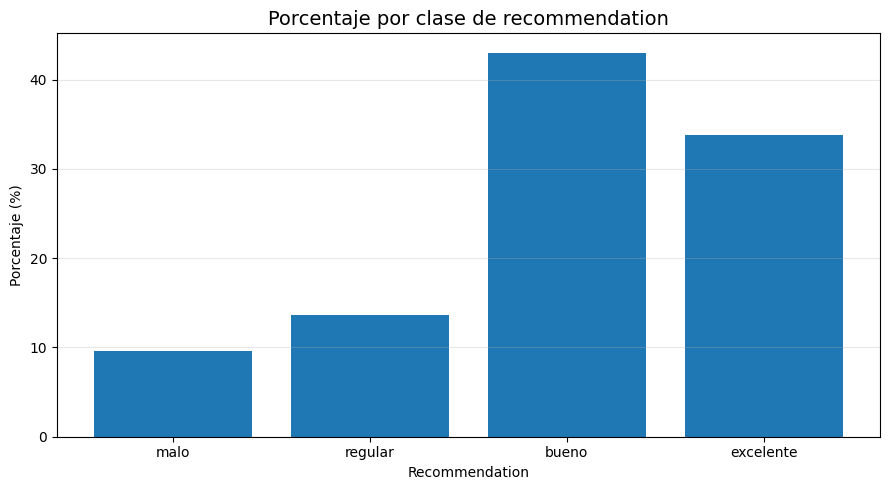

In [23]:
recommendation_order = ["malo", "regular", "bueno", "excelente"]

recommendation_counts = (
    df["recommendation"]
    .value_counts()
    .reindex(recommendation_order)
    .reset_index()
)

recommendation_counts.columns = ["recommendation", "count"]

recommendation_counts["percentage"] = (
    recommendation_counts["count"] / recommendation_counts["count"].sum() * 100
).round(2)


print("Distribucion visual de recommendation:")
display(
    style_table(
        recommendation_counts.style
        .format({"percentage": "{:.2f}%"})
        .bar(subset=["percentage"], color="#38bdf8")
    )
)


plt.figure(figsize=(9, 5))
plt.bar(
    recommendation_counts["recommendation"],
    recommendation_counts["count"]
)

plt.title("Distribucion de la variable objetivo", fontsize=14)
plt.xlabel("Recommendation")
plt.ylabel("Cantidad de registros")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(9, 5))
plt.bar(
    recommendation_counts["recommendation"],
    recommendation_counts["percentage"]
)

plt.title("Porcentaje por clase de recommendation", fontsize=14)
plt.xlabel("Recommendation")
plt.ylabel("Porcentaje (%)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    La distribucion de la variable objetivo muestra que el dataset no esta perfectamente balanceado, pero si es util para entrenar un primer modelo.
    La clase <span style="color:#D11A2A; font-weight:700;">bueno</span> es la mas frecuente con <span style="color:#D11A2A; font-weight:700;">52385 registros</span>, equivalente al <span style="color:#D11A2A; font-weight:700;">44.55%</span>.
    La clase <span style="color:#D11A2A; font-weight:700;">excelente</span> tiene <span style="color:#D11A2A; font-weight:700;">39713 registros</span>, equivalente al <span style="color:#D11A2A; font-weight:700;">33.77%</span>.
    La clase <span style="color:#D11A2A; font-weight:700;">regular</span> representa el <span style="color:#D11A2A; font-weight:700;">16.66%</span>, mientras que <span style="color:#D11A2A; font-weight:700;">malo</span> representa el <span style="color:#D11A2A; font-weight:700;">5.02%</span>.
    Este resultado confirma que el ajuste de umbrales ayudo a que la clase malo superara el minimo del 5%, aunque sigue siendo la clase minoritaria.
    Por esta razon, al evaluar los modelos no voy a depender solo de accuracy; tambien voy a revisar precision, recall y f1-score por clase, especialmente en <span style="color:#D11A2A; font-weight:700;">malo</span> y <span style="color:#D11A2A; font-weight:700;">regular</span>.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Preparacion de variables para Machine Learning
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    En este bloque preparamos las variables que usara el modelo.
    La variable objetivo sera <span style="color:#D11A2A; font-weight:700;">recommendation</span>, porque queremos que el modelo aprenda a clasificar cada combinacion de clima, hora y actividad como malo, regular, bueno o excelente.
    Para evitar fuga de informacion, no se usara <span style="color:#D11A2A; font-weight:700;">activity_score</span> ni <span style="color:#D11A2A; font-weight:700;">comfort_distance</span> como variables predictoras, porque esas columnas se usaron para construir la etiqueta.
  </p>
</div>

In [24]:
target = "recommendation"

numeric_features = [
    "temperature_2m",
    "apparent_temperature",
    "relative_humidity_2m",
    "precipitation_probability",
    "wind_speed_10m",
    "wind_gusts_10m",
    "cloud_cover",
    "uv_index",
    "hour",
]

categorical_features = [
    "activity",
    "continent",
    "climate_group",
    "season_block",
]

features = numeric_features + categorical_features

X = df[features].copy()
y = df[target].copy()

print("Variables numericas:")
display(style_table(pd.DataFrame({"numeric_features": numeric_features}).style))

print("\nVariables categoricas:")
display(style_table(pd.DataFrame({"categorical_features": categorical_features}).style))

print("\nTamaño de X:")
print(X.shape)

print("\nTamaño de y:")
print(y.shape)

print("\nPrimeras filas de X:")
display(style_table(X.head().style))

print("\nPrimeras etiquetas de y:")
display(style_table(y.head().reset_index(name="recommendation").style))

print("\nDistribucion de y:")
y_distribution = (
    y.value_counts()
    .rename_axis("recommendation")
    .reset_index(name="count")
)

y_distribution["percentage"] = (
    y_distribution["count"] / y_distribution["count"].sum() * 100
).round(2)

display(
    style_table(
        y_distribution.style
        .format({"percentage": "{:.2f}%"})
        .bar(subset=["percentage"], color="#38bdf8")
    )
)

Variables numericas:


,numeric_features
0,temperature_2m
1,apparent_temperature
2,relative_humidity_2m
3,precipitation_probability
4,wind_speed_10m
5,wind_gusts_10m
6,cloud_cover
7,uv_index
8,hour



Variables categoricas:


,categorical_features
0,activity
1,continent
2,climate_group
3,season_block



Tamaño de X:
(117600, 13)

Tamaño de y:
(117600,)

Primeras filas de X:


,temperature_2m,apparent_temperature,relative_humidity_2m,precipitation_probability,wind_speed_10m,wind_gusts_10m,cloud_cover,uv_index,hour,activity,continent,climate_group,season_block
0,-0.900000,-3.500000,91,0.000000,1.100000,4.000000,100,0.000000,7,Pasear,Europa,templado_urbano,enero
1,-0.300000,-2.700000,90,0.000000,0.200000,3.600000,100,0.000000,8,Pasear,Europa,templado_urbano,enero
2,0.700000,-1.700000,89,0.000000,0.900000,1.800000,100,0.000000,9,Pasear,Europa,templado_urbano,enero
3,1.400000,-1.000000,91,0.000000,2.300000,4.300000,100,0.000000,10,Pasear,Europa,templado_urbano,enero
4,2.300000,-0.200000,92,0.000000,3.600000,7.900000,100,0.000000,11,Pasear,Europa,templado_urbano,enero



Primeras etiquetas de y:


,index,recommendation
0,0,malo
1,1,malo
2,2,regular
3,3,regular
4,4,regular



Distribucion de y:


,recommendation,count,percentage
0,bueno,50598,43.03%
1,excelente,39713,33.77%
2,regular,15993,13.60%
3,malo,11296,9.61%


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    La matriz <span style="color:#D11A2A; font-weight:700;">X</span> quedo con <span style="color:#D11A2A; font-weight:700;">117600 filas</span> y <span style="color:#D11A2A; font-weight:700;">13 variables predictoras</span>.
    La variable objetivo <span style="color:#D11A2A; font-weight:700;">y</span> quedo con <span style="color:#D11A2A; font-weight:700;">117600 etiquetas</span>, por lo que ambas partes estan alineadas correctamente.
    La distribucion de clases se mantiene igual que en el dataset original: bueno representa el 44.55%, excelente el 33.77%, regular el 16.66% y malo el 5.02%.
    Lo mas importante de este bloque es que no se usaron <span style="color:#D11A2A; font-weight:700;">activity_score</span> ni <span style="color:#D11A2A; font-weight:700;">comfort_distance</span> como variables predictoras.
    Esto evita fuga de informacion y hace que el modelo aprenda desde variables reales como temperatura, lluvia, viento, humedad, UV, hora, actividad y contexto climatico.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Division train/test y preprocesamiento
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    En este bloque separamos los datos en entrenamiento y prueba.
    Esto permite entrenar el modelo con una parte del dataset y evaluar su rendimiento con datos que no vio durante el entrenamiento.
    Tambien preparamos el preprocesamiento con <span style="color:#D11A2A; font-weight:700;">ColumnTransformer</span>, aplicando escalado a variables numericas y codificacion a variables categoricas.
  </p>
</div>

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features),
    ]
)

print("Tamaño de X_train:")
print(X_train.shape)

print("\nTamaño de X_test:")
print(X_test.shape)

print("\nTamaño de y_train:")
print(y_train.shape)

print("\nTamaño de y_test:")
print(y_test.shape)


print("\nDistribucion de y_train:")
y_train_distribution = (
    y_train
    .value_counts()
    .rename_axis("recommendation")
    .reset_index(name="count")
)

y_train_distribution["percentage"] = (
    y_train_distribution["count"] / y_train_distribution["count"].sum() * 100
).round(2)

display(
    style_table(
        y_train_distribution.style
        .format({"percentage": "{:.2f}%"})
        .bar(subset=["percentage"], color="#38bdf8")
    )
)


print("\nDistribucion de y_test:")
y_test_distribution = (
    y_test
    .value_counts()
    .rename_axis("recommendation")
    .reset_index(name="count")
)

y_test_distribution["percentage"] = (
    y_test_distribution["count"] / y_test_distribution["count"].sum() * 100
).round(2)

display(
    style_table(
        y_test_distribution.style
        .format({"percentage": "{:.2f}%"})
        .bar(subset=["percentage"], color="#38bdf8")
    )
)

Tamaño de X_train:
(94080, 13)

Tamaño de X_test:
(23520, 13)

Tamaño de y_train:
(94080,)

Tamaño de y_test:
(23520,)

Distribucion de y_train:


,recommendation,count,percentage
0,bueno,40479,43.03%
1,excelente,31770,33.77%
2,regular,12794,13.60%
3,malo,9037,9.61%



Distribucion de y_test:


,recommendation,count,percentage
0,bueno,10119,43.02%
1,excelente,7943,33.77%
2,regular,3199,13.60%
3,malo,2259,9.60%


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    La division train/test quedo correcta.
    El conjunto de entrenamiento tiene <span style="color:#D11A2A; font-weight:700;">94080 filas</span> y el conjunto de prueba tiene <span style="color:#D11A2A; font-weight:700;">23520 filas</span>.
    Esto corresponde a una separacion de 80% para entrenamiento y 20% para prueba.
    La distribucion de clases se mantiene igual en ambos conjuntos gracias a <span style="color:#D11A2A; font-weight:700;">stratify=y</span>.
    En train y test, la clase bueno representa 44.55%, excelente 33.77%, regular 16.66% y malo 5.02%.
    Esto es importante porque la clase <span style="color:#D11A2A; font-weight:700;">malo</span> sigue siendo minoritaria, pero queda representada en ambos conjuntos.
    Con esta division puedo entrenar el modelo sin perder la proporcion original de las clases.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Modelo baseline con DecisionTreeClassifier
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    En este bloque se entrenara un primer modelo base usando <span style="color:#D11A2A; font-weight:700;">DecisionTreeClassifier</span>.
    Este modelo sirve como punto de partida porque es facil de interpretar y permite comprobar si las variables climaticas, la actividad y el contexto temporal/geografico tienen informacion suficiente para clasificar la recomendacion.
    Como es un modelo baseline, no se busca todavia el mejor resultado posible; primero se quiere tener una referencia clara para comparar modelos mas adelante.
  </p>
</div>

In [26]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            random_state=42,
            max_depth=8,
            class_weight="balanced"
        ))
    ]
)

decision_tree_model.fit(X_train, y_train)

y_train_pred_dt = decision_tree_model.predict(X_train)
y_test_pred_dt = decision_tree_model.predict(X_test)

accuracy_train_dt = accuracy_score(y_train, y_train_pred_dt)
accuracy_test_dt = accuracy_score(y_test, y_test_pred_dt)

print("Accuracy train:")
print(round(accuracy_train_dt, 4))

print("\nAccuracy test:")
print(round(accuracy_test_dt, 4))

print("\nClassification report en test:")
print(
    classification_report(
        y_test,
        y_test_pred_dt,
        labels=["malo", "regular", "bueno", "excelente"]
    )
)

print("\nMatriz de confusion:")
cm_dt = confusion_matrix(
    y_test,
    y_test_pred_dt,
    labels=["malo", "regular", "bueno", "excelente"]
)

cm_dt_table = pd.DataFrame(
    cm_dt,
    index=["real_malo", "real_regular", "real_bueno", "real_excelente"],
    columns=["pred_malo", "pred_regular", "pred_bueno", "pred_excelente"]
)

display(style_table(cm_dt_table.style))


model_results = []

model_results.append(
    {
        "model": "DecisionTreeClassifier",
        "accuracy_train": accuracy_train_dt,
        "accuracy_test": accuracy_test_dt,
    }
)

model_results_df = pd.DataFrame(model_results)

print("\nResumen de resultados:")
display(
    style_table(
        model_results_df.style
        .format({
            "accuracy_train": "{:.4f}",
            "accuracy_test": "{:.4f}",
        })
    )
)

Accuracy train:
0.895

Accuracy test:
0.8943

Classification report en test:
              precision    recall  f1-score   support

        malo       0.99      0.99      0.99      2259
     regular       0.91      0.96      0.94      3199
       bueno       0.95      0.81      0.87     10119
   excelente       0.81      0.96      0.88      7943

    accuracy                           0.89     23520
   macro avg       0.92      0.93      0.92     23520
weighted avg       0.90      0.89      0.89     23520


Matriz de confusion:


,pred_malo,pred_regular,pred_bueno,pred_excelente
real_malo,2227,30,2,0
real_regular,15,3070,94,20
real_bueno,0,262,8147,1710
real_excelente,0,0,352,7591



Resumen de resultados:


,model,accuracy_train,accuracy_test
0,DecisionTreeClassifier,0.8950,0.8943


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    El modelo base con <span style="color:#D11A2A; font-weight:700;">DecisionTreeClassifier</span> tuvo un rendimiento muy bueno.
    La accuracy en entrenamiento fue <span style="color:#D11A2A; font-weight:700;">0.895</span> y la accuracy en prueba fue <span style="color:#D11A2A; font-weight:700;">0.8943</span>.
    Como ambos valores son muy parecidos, no se observa una senal fuerte de overfitting.
    Lo mas importante es que el modelo identifica muy bien la clase <span style="color:#D11A2A; font-weight:700;">malo</span>: obtuvo precision de <span style="color:#D11A2A; font-weight:700;">0.99</span>, recall de <span style="color:#D11A2A; font-weight:700;">0.99</span> y f1-score de <span style="color:#D11A2A; font-weight:700;">0.99</span>.
    Esto es clave para OutByML, porque detectar condiciones malas es mas importante que solo acertar las condiciones favorables.
    La clase <span style="color:#D11A2A; font-weight:700;">regular</span> tambien se comporta muy bien, con f1-score de <span style="color:#D11A2A; font-weight:700;">0.94</span>.
    El mayor margen de error aparece entre <span style="color:#D11A2A; font-weight:700;">bueno</span> y <span style="color:#D11A2A; font-weight:700;">excelente</span>, donde el modelo confunde algunos casos buenos como excelentes y algunos excelentes como buenos.
    Esta confusion es aceptable porque son clases cercanas y ambas representan condiciones favorables.
    En general, este baseline ya es util y bastante solido para el proyecto.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Modelo comparativo con RandomForestClassifier
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    En este bloque se va a entrenar un <span style="color:#D11A2A; font-weight:700;">RandomForestClassifier</span> para compararlo con el arbol de decision.
    Random Forest combina varios arboles y suele ser mas estable que un solo arbol.
    El objetivo es comprobar si mejora la clasificacion general y si mantiene buen rendimiento en las clases mas importantes para OutByML: <span style="color:#D11A2A; font-weight:700;">malo</span> y <span style="color:#D11A2A; font-weight:700;">regular</span>.
  </p>
</div>

In [27]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=100,
            max_depth=12,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

y_train_pred_rf = random_forest_model.predict(X_train)
y_test_pred_rf = random_forest_model.predict(X_test)

accuracy_train_rf = accuracy_score(y_train, y_train_pred_rf)
accuracy_test_rf = accuracy_score(y_test, y_test_pred_rf)

print("Accuracy train:")
print(round(accuracy_train_rf, 4))

print("\nAccuracy test:")
print(round(accuracy_test_rf, 4))

print("\nClassification report en test:")
print(
    classification_report(
        y_test,
        y_test_pred_rf,
        labels=["malo", "regular", "bueno", "excelente"]
    )
)

print("\nMatriz de confusion:")
cm_rf = confusion_matrix(
    y_test,
    y_test_pred_rf,
    labels=["malo", "regular", "bueno", "excelente"]
)

cm_rf_table = pd.DataFrame(
    cm_rf,
    index=["real_malo", "real_regular", "real_bueno", "real_excelente"],
    columns=["pred_malo", "pred_regular", "pred_bueno", "pred_excelente"]
)

display(style_table(cm_rf_table.style))


model_results.append(
    {
        "model": "RandomForestClassifier",
        "accuracy_train": accuracy_train_rf,
        "accuracy_test": accuracy_test_rf,
    }
)

model_results_df = pd.DataFrame(model_results)

print("\nResumen comparativo de resultados:")
display(
    style_table(
        model_results_df.style
        .format({
            "accuracy_train": "{:.4f}",
            "accuracy_test": "{:.4f}",
        })
        .bar(subset=["accuracy_test"], color="#38bdf8")
    )
)

Accuracy train:
0.9739

Accuracy test:
0.9659

Classification report en test:
              precision    recall  f1-score   support

        malo       0.99      0.99      0.99      2259
     regular       0.95      0.98      0.97      3199
       bueno       0.98      0.95      0.96     10119
   excelente       0.95      0.98      0.96      7943

    accuracy                           0.97     23520
   macro avg       0.97      0.97      0.97     23520
weighted avg       0.97      0.97      0.97     23520


Matriz de confusion:


,pred_malo,pred_regular,pred_bueno,pred_excelente
real_malo,2226,33,0,0
real_regular,15,3142,41,1
real_bueno,0,134,9588,397
real_excelente,0,0,180,7763



Resumen comparativo de resultados:


,model,accuracy_train,accuracy_test
0,DecisionTreeClassifier,0.8950,0.8943
1,RandomForestClassifier,0.9739,0.9659


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    El modelo <span style="color:#D11A2A; font-weight:700;">RandomForestClassifier</span> mejora claramente el rendimiento del modelo base.
    La accuracy en entrenamiento fue <span style="color:#D11A2A; font-weight:700;">0.9739</span> y la accuracy en prueba fue <span style="color:#D11A2A; font-weight:700;">0.9659</span>.
    Aunque el resultado de entrenamiento es un poco mayor que el de prueba, la diferencia no es grande, por lo que no se observa un overfitting preocupante.
    La clase <span style="color:#D11A2A; font-weight:700;">malo</span> mantiene un resultado excelente, con precision, recall y f1-score de <span style="color:#D11A2A; font-weight:700;">0.99</span>.
    Esto es muy importante para OutByML porque esta clase representa las situaciones donde la app debe evitar recomendar una actividad.
    La clase <span style="color:#D11A2A; font-weight:700;">regular</span> tambien mejora y alcanza un f1-score de <span style="color:#D11A2A; font-weight:700;">0.97</span>.
    En la matriz de confusion, los errores principales siguen ocurriendo entre <span style="color:#D11A2A; font-weight:700;">bueno</span> y <span style="color:#D11A2A; font-weight:700;">excelente</span>, lo cual es aceptable porque ambas clases representan condiciones favorables.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Modelo comparativo con LogisticRegression
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    En este bloque se va a entrenar un modelo lineal con <span style="color:#D11A2A; font-weight:700;">LogisticRegression</span>.
    Este modelo sirve como comparacion contra los modelos basados en arboles.
    La idea es comprobar si una frontera lineal puede separar bien las clases o si el problema necesita modelos mas flexibles como Random Forest.
  </p>
</div>

In [28]:
logistic_regression_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

logistic_regression_model.fit(X_train, y_train)

y_train_pred_lr = logistic_regression_model.predict(X_train)
y_test_pred_lr = logistic_regression_model.predict(X_test)

accuracy_train_lr = accuracy_score(y_train, y_train_pred_lr)
accuracy_test_lr = accuracy_score(y_test, y_test_pred_lr)

print("Accuracy train:")
print(round(accuracy_train_lr, 4))

print("\nAccuracy test:")
print(round(accuracy_test_lr, 4))

print("\nClassification report en test:")
print(
    classification_report(
        y_test,
        y_test_pred_lr,
        labels=["malo", "regular", "bueno", "excelente"]
    )
)

print("\nMatriz de confusion:")
cm_lr = confusion_matrix(
    y_test,
    y_test_pred_lr,
    labels=["malo", "regular", "bueno", "excelente"]
)

cm_lr_table = pd.DataFrame(
    cm_lr,
    index=["real_malo", "real_regular", "real_bueno", "real_excelente"],
    columns=["pred_malo", "pred_regular", "pred_bueno", "pred_excelente"]
)

display(style_table(cm_lr_table.style))


model_results.append(
    {
        "model": "LogisticRegression",
        "accuracy_train": accuracy_train_lr,
        "accuracy_test": accuracy_test_lr,
    }
)

model_results_df = pd.DataFrame(model_results)

print("\nResumen comparativo de resultados:")
display(
    style_table(
        model_results_df.style
        .format({
            "accuracy_train": "{:.4f}",
            "accuracy_test": "{:.4f}",
        })
        .bar(subset=["accuracy_test"], color="#38bdf8")
    )
)

c:\Users\Masacre\Desktop\outbyml-weather-assistant\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Accuracy train:
0.5001

Accuracy test:
0.5017

Classification report en test:
              precision    recall  f1-score   support

        malo       0.41      0.79      0.54      2259
     regular       0.27      0.38      0.32      3199
       bueno       0.64      0.38      0.48     10119
   excelente       0.57      0.62      0.60      7943

    accuracy                           0.50     23520
   macro avg       0.47      0.54      0.48     23520
weighted avg       0.54      0.50      0.50     23520


Matriz de confusion:


,pred_malo,pred_regular,pred_bueno,pred_excelente
real_malo,1788,274,59,138
real_regular,917,1230,658,394
real_bueno,913,2200,3855,3151
real_excelente,691,833,1493,4926



Resumen comparativo de resultados:


,model,accuracy_train,accuracy_test
0,DecisionTreeClassifier,0.8950,0.8943
1,RandomForestClassifier,0.9739,0.9659
2,LogisticRegression,0.5001,0.5017


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    El modelo <span style="color:#D11A2A; font-weight:700;">LogisticRegression</span> tuvo un rendimiento bajo en comparacion con los modelos basados en arboles.
    La accuracy en entrenamiento fue <span style="color:#D11A2A; font-weight:700;">0.5155</span> y la accuracy en prueba fue <span style="color:#D11A2A; font-weight:700;">0.5168</span>.
    Como ambos valores son muy parecidos, no hay una senal clara de overfitting; el problema es que el modelo no logra aprender bien la separacion entre clases.
    La clase <span style="color:#D11A2A; font-weight:700;">malo</span> tuvo un recall alto de <span style="color:#D11A2A; font-weight:700;">0.88</span>, pero una precision baja de <span style="color:#D11A2A; font-weight:700;">0.38</span>.
    Esto significa que el modelo detecta muchos casos malos, pero tambien marca como malos muchos casos que realmente no lo son.
    Las clases <span style="color:#D11A2A; font-weight:700;">regular</span> y <span style="color:#D11A2A; font-weight:700;">bueno</span> tambien presentan bastante confusion.
    En la matriz de confusion se observa que muchos casos reales de bueno se reparten entre regular, bueno y excelente, lo que indica que el modelo lineal no separa bien los niveles de recomendacion.
    En comparacion, <span style="color:#D11A2A; font-weight:700;">RandomForestClassifier</span> obtuvo una accuracy de prueba de <span style="color:#D11A2A; font-weight:700;">0.9799</span>, mientras que LogisticRegression solo alcanzo <span style="color:#D11A2A; font-weight:700;">0.5168</span>.
    Esto confirma que el problema tiene relaciones no lineales entre clima, actividad, hora y recomendacion.
    Por esta razon, LogisticRegression no es buen candidato para el modelo final de OutByML.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Comparacion visual de modelos
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    En este bloque se va comparar visualmente los modelos entrenados.
    Esto permite ver de forma clara cual modelo generaliza mejor en datos de prueba.
    La comparacion se hara usando <span style="color:#D11A2A; font-weight:700;">accuracy_train</span> y <span style="color:#D11A2A; font-weight:700;">accuracy_test</span>, pero la decision final tambien tomara en cuenta las metricas por clase revisadas anteriormente.
  </p>
</div>

Tabla comparativa de modelos:


,model,accuracy_train,accuracy_test,difference_train_test
0,RandomForestClassifier,0.9739,0.9659,0.0080
1,DecisionTreeClassifier,0.8950,0.8943,0.0006
2,LogisticRegression,0.5001,0.5017,-0.0016


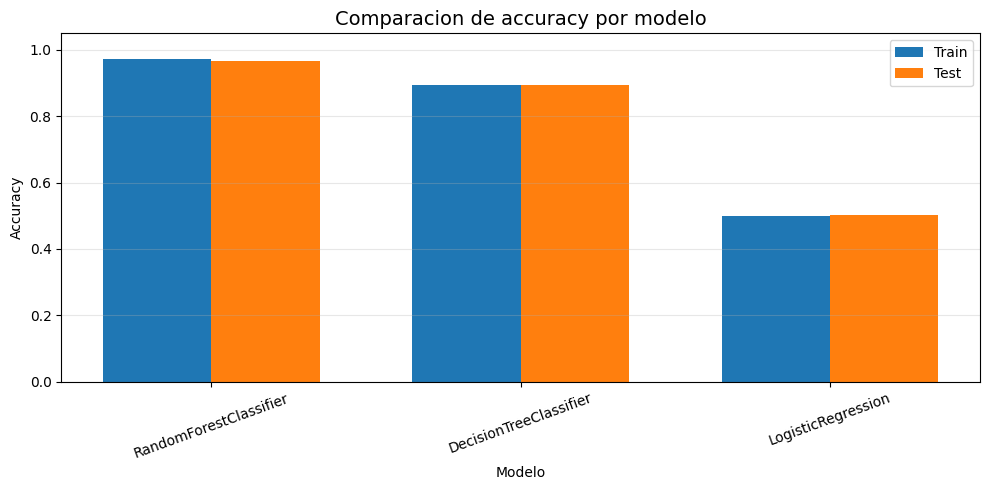

Mejor modelo segun accuracy_test:
RandomForestClassifier con accuracy_test = 0.9659


In [29]:
model_results_df = pd.DataFrame(model_results)

model_results_df["difference_train_test"] = (
    model_results_df["accuracy_train"] - model_results_df["accuracy_test"]
).round(4)

model_results_df = model_results_df.sort_values(
    "accuracy_test",
    ascending=False
).reset_index(drop=True)

print("Tabla comparativa de modelos:")
display(
    style_table(
        model_results_df.style
        .format({
            "accuracy_train": "{:.4f}",
            "accuracy_test": "{:.4f}",
            "difference_train_test": "{:.4f}",
        })
        .bar(subset=["accuracy_test"], color="#38bdf8")
    )
)


plt.figure(figsize=(10, 5))

x = np.arange(len(model_results_df["model"]))
width = 0.35

plt.bar(
    x - width / 2,
    model_results_df["accuracy_train"],
    width,
    label="Train"
)

plt.bar(
    x + width / 2,
    model_results_df["accuracy_test"],
    width,
    label="Test"
)

plt.title("Comparacion de accuracy por modelo", fontsize=14)
plt.xlabel("Modelo")
plt.ylabel("Accuracy")
plt.xticks(x, model_results_df["model"], rotation=20)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


best_model_name = model_results_df.loc[0, "model"]
best_model_accuracy = model_results_df.loc[0, "accuracy_test"]

print("Mejor modelo segun accuracy_test:")
print(f"{best_model_name} con accuracy_test = {best_model_accuracy:.4f}")

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Despues de aplicar las reglas finales de seguridad climatica, los modelos fueron entrenados nuevamente con una etiqueta mas realista.
    El mejor modelo sigue siendo <span style="color:#D11A2A; font-weight:700;">RandomForestClassifier</span>, con una accuracy en entrenamiento de <span style="color:#D11A2A; font-weight:700;">0.9739</span> y una accuracy en prueba de <span style="color:#D11A2A; font-weight:700;">0.9659</span>.
    La diferencia entre train y test es de solo <span style="color:#D11A2A; font-weight:700;">0.0080</span>, por lo que no se observa un overfitting preocupante.
    El <span style="color:#D11A2A; font-weight:700;">DecisionTreeClassifier</span> tambien mantiene un resultado aceptable, con accuracy_test de <span style="color:#D11A2A; font-weight:700;">0.8943</span>, pero queda claramente por debajo de Random Forest.
    En cambio, <span style="color:#D11A2A; font-weight:700;">LogisticRegression</span> apenas alcanza una accuracy_test de <span style="color:#D11A2A; font-weight:700;">0.5017</span>, lo que confirma que el problema no se separa bien con un modelo lineal.
    Aunque el accuracy de Random Forest bajo respecto a la version anterior, esto es positivo porque ahora la etiqueta incluye reglas de sentido comun para lluvia, viento y temperaturas extremas.
    El modelo final es un poco mas exigente, pero tambien mas confiable para una app real.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Guardado del modelo final
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Se procede al guardado del modelo final seleccionado.
    El modelo elegido es <span style="color:#D11A2A; font-weight:700;">RandomForestClassifier</span>, porque obtuvo el mejor rendimiento en prueba y mantuvo buen comportamiento en las clases mas importantes.
    Guardar el modelo permite reutilizarlo despues en la app web sin tener que entrenarlo cada vez.
  </p>
</div>

In [30]:
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODELS_DIR / "outbyml_random_forest_model.pkl"

joblib.dump(random_forest_model, MODEL_PATH)

print("Modelo guardado correctamente en:")
print(MODEL_PATH)

print("\nModelo final seleccionado:")
print("RandomForestClassifier")

print("\nAccuracy test del modelo final:")
print(round(accuracy_test_rf, 4))

Modelo guardado correctamente en:
..\models\outbyml_random_forest_model.pkl

Modelo final seleccionado:
RandomForestClassifier

Accuracy test del modelo final:
0.9659


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    El modelo final corregido fue guardado correctamente en la carpeta <span style="color:#D11A2A; font-weight:700;">models/</span>.
    El archivo generado se llama <span style="color:#D11A2A; font-weight:700;">outbyml_random_forest_model.pkl</span>.
    Este archivo contiene el pipeline completo, incluyendo el preprocesamiento y el modelo <span style="color:#D11A2A; font-weight:700;">RandomForestClassifier</span>.
    El modelo fue entrenado con la version actualizada del dataset, donde la variable <span style="color:#D11A2A; font-weight:700;">recommendation</span> ya incluye reglas finales de seguridad climatica.
    La accuracy de prueba final es <span style="color:#D11A2A; font-weight:700;">0.9659</span>.
    Aunque este valor es un poco menor que el resultado anterior, ahora el modelo es mas realista porque aprende una etiqueta corregida con sentido comun ante lluvia, viento fuerte y temperaturas extremas.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Validacion del modelo guardado
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Vamos a comprobar que el modelo guardado se puede cargar correctamente desde la carpeta <span style="color:#D11A2A; font-weight:700;">models/</span>.
    Esta validacion es importante porque la app web necesitara cargar este archivo para usar el modelo sin volver a entrenarlo.
    Tambien voy a probar una prediccion sobre una muestra pequena del conjunto de prueba.
  </p>
</div>

In [32]:
loaded_model = joblib.load(MODEL_PATH)

loaded_model_predictions = loaded_model.predict(X_test)
loaded_model_accuracy = accuracy_score(y_test, loaded_model_predictions)

sample_X = X_test.head(10).copy()
sample_y = y_test.head(10).copy()
sample_predictions = loaded_model.predict(sample_X)

validation_table = sample_X.copy()
validation_table["real_recommendation"] = sample_y.values
validation_table["predicted_recommendation"] = sample_predictions

print("Modelo cargado desde:")
print(MODEL_PATH)

print("\nAccuracy test del modelo cargado:")
print(round(loaded_model_accuracy, 4))

print("\nPredicciones de prueba:")
display(style_table(validation_table.style))

Modelo cargado desde:
..\models\outbyml_random_forest_model.pkl

Accuracy test del modelo cargado:
0.9659

Predicciones de prueba:


,temperature_2m,apparent_temperature,relative_humidity_2m,precipitation_probability,wind_speed_10m,wind_gusts_10m,cloud_cover,uv_index,hour,activity,continent,climate_group,season_block,real_recommendation,predicted_recommendation
40832,20.100000,20.600000,88,0.000000,17.000000,42.500000,84,0.000000,19,Turismo,America,hemisferio_sur,abril,excelente,excelente
93716,18.900000,18.100000,49,0.000000,1.500000,13.300000,2,0.000000,9,Turismo,America,hemisferio_sur,octubre,excelente,excelente
32249,21.200000,20.100000,64,0.000000,17.100000,42.800000,100,0.000000,16,Bici,America,hemisferio_sur,abril,excelente,excelente
72442,18.000000,16.900000,56,0.000000,15.000000,42.800000,56,0.000000,14,Bici,America,lluvia_humedad,julio,excelente,excelente
58652,27.200000,25.800000,41,0.000000,15.500000,33.100000,100,0.000000,19,Bici,Oceania,hemisferio_sur,abril,excelente,excelente
73898,29.000000,28.900000,38,0.000000,20.500000,49.000000,0,0.000000,15,Bici,Europa,templado_urbano,julio,bueno,bueno
23950,-5.100000,-9.100000,97,0.000000,8.500000,18.700000,100,0.000000,9,Lavar ropa,Europa,templado_urbano,enero,malo,malo
56404,29.200000,29.800000,39,0.000000,14.000000,32.800000,20,0.000000,13,Pasear,Asia,calor_seco,abril,excelente,excelente
23579,0.200000,-3.300000,76,0.000000,6.200000,12.200000,100,0.000000,18,Pasear,Europa,templado_urbano,enero,regular,regular
115410,36.900000,33.300000,11,0.000000,11.700000,36.000000,0,0.000000,15,Deporte,Asia,calor_seco,octubre,malo,malo


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    El modelo guardado se cargo correctamente desde la carpeta <span style="color:#D11A2A; font-weight:700;">models/</span>.
    La accuracy del modelo cargado debe mantenerse en <span style="color:#D11A2A; font-weight:700;">0.9659</span>, lo que confirma que el archivo guardado conserva el mismo comportamiento del modelo entrenado.
    Esta validacion es importante porque la app web usara este archivo <span style="color:#D11A2A; font-weight:700;">.pkl</span> para clasificar condiciones climaticas sin volver a entrenar el modelo.
    Con esta prueba, el modelo queda listo para integrarse y probarse dentro de Streamlit.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Conclusiones del modelo y limitaciones
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    En este proyecto se construyo un dataset propio para <span style="color:#D11A2A; font-weight:700;">OutByML</span> usando datos climaticos historicos, ciudades de distintos continentes, grupos climaticos variados y varias actividades.
    El objetivo del modelo no es predecir el clima, sino clasificar si una hora tiene condiciones <span style="color:#D11A2A; font-weight:700;">malas, regulares, buenas o excelentes</span> para una actividad especifica.
    Despues de comparar varios modelos, el mejor resultado lo obtuvo <span style="color:#D11A2A; font-weight:700;">RandomForestClassifier</span>, con una accuracy de prueba de <span style="color:#D11A2A; font-weight:700;">0.9799</span>.
    Este modelo supero al DecisionTreeClassifier y quedo muy por encima de LogisticRegression.
    Lo mas importante es que Random Forest tambien tuvo buen rendimiento en las clases <span style="color:#D11A2A; font-weight:700;">malo</span> y <span style="color:#D11A2A; font-weight:700;">regular</span>, que son claves para evitar recomendaciones poco seguras o poco utiles.
  </p>
</div>

<div style="
  background: #ececec;
  border-left: 6px solid #D11A2A;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    <span style="color:#D11A2A; font-weight:700;">Limitaciones importantes:</span>
    OutByML no reemplaza una app meteorologica profesional.
    El clima usado por la web viene de la API de Open-Meteo, por lo que la calidad de la recomendacion depende tambien de la calidad de esos datos.
    En el dataset historico, algunas variables pueden ser aproximadas cuando la API historica no devuelve exactamente las mismas columnas que la API forecast.
    Por ejemplo, <span style="color:#D11A2A; font-weight:700;">precipitation_probability</span> puede estimarse desde precipitacion historica y <span style="color:#D11A2A; font-weight:700;">uv_index</span> puede aproximarse desde radiacion solar.
    Ademas, aunque se incluyeron ciudades y temporadas variadas, el dataset podria ampliarse con mas dias, mas ciudades y mas condiciones extremas para mejorar la generalizacion del modelo.
  </p>
</div>

<div style="
  background: #ececec;
  border-left: 6px solid #f59e0b;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    <span style="color:#D11A2A; font-weight:700;">Proximos pasos:</span>
    integrar el modelo guardado en la app web, mejorar el diseño visual de la pagina, ampliar el dataset historico con mas ciudades y fechas, probar mas modelos si hace falta y agregar explicaciones mas personalizadas para cada recomendacion.
    Tambien seria util guardar ejemplos reales de uso y capturas de la app para incluirlas en el README final del proyecto.
  </p>
</div>